# Experiments with XGBoost model

## Imports and Environment Setup

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# To suppress TF Warnings:
os.environ['TF_CPP_MIN_LOG_LEVEL']= '2'

2026-07-06 12:16:22.901837: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-06 12:16:24.211810: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-06 12:16:26.946862: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/export/tf2onnx_li

## Dataset Loading (TFRecords)

In [15]:
# Project Root Folder:
PROJECT_ROOT= os.path.dirname(os.getcwd())
print(PROJECT_ROOT)

# DataSet Path:
DATASET_PATH= 'data/processed/features.tfrecord'
print(DATASET_PATH)

# TFRecords Path:
TFRECORD_PATH= os.path.join(PROJECT_ROOT, DATASET_PATH)
print(TFRECORD_PATH)

/home/shail/disaster_triage_pipeline
data/processed/features.tfrecord
/home/shail/disaster_triage_pipeline/data/processed/features.tfrecord


In [ ]:
# Fuction to Parse a Single tf.train.Example element:
def parse_tfr_element(element):
    """
    Parses a single tf.train.Example protocol buffer.
    """
    data= {
        'building_id': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.string),
        'feature_vector': tf.io.FixedLenFeature([2048], tf.float32)
    }

    content= tf.io.parse_single_example(element, data)
    return content['feature_vector'], content['label'], content['building_id']

In [19]:

# Function to Load TFRecords Dataset and Convert it into Numpy Arrays:
def load_dataset(filepath):
    """
    Loads the TFRecord dataset and converts it to numpy arrays.
    """
    print('Unpacking TFRecords Dataset...')
    dataset= tf.data.TFRecordDataset(filenames= filepath)
    dataset= dataset.map(parse_tfr_element)

    X_list, y_list, id_list= [], [], []

    for features, label, b_id in dataset:
        X_list.append(features.numpy())
        y_list.append(label.numpy().decode('utf-8'))
        id_list.append(b_id.numpy().decode('utf-8'))
    
    X= np.array(X_list)
    y= np.array(y_list)
    ids= np.array(id_list)

    print(f'Successfully Loaded {X.shape[0]} Records.')
    print(f'Feature Matrix Shape: {X.shape}')

    return X, y, ids

In [20]:
# Loding TFRecords Dataset into Numpy Array:
X_raw, y_raw, building_ids= load_dataset(filepath= TFRECORD_PATH)

Unpacking TFRecords Dataset...
Successfully Loaded 162787 Records.
Feature Matrix Shape: (162787, 2048)


## Data Pre-Processing

In [21]:
X_raw

array([[0.03903551, 0.14880732, 0.13893297, ..., 0.7189002 , 0.16941108,
        0.111853  ],
       [0.24977316, 0.08506289, 0.0210791 , ..., 0.01439446, 0.37462792,
        0.02411834],
       [0.7700253 , 0.02744852, 0.02121252, ..., 3.1549957 , 2.186299  ,
        0.26314795],
       ...,
       [0.06229302, 0.22243787, 0.50739115, ..., 2.6689954 , 0.        ,
        0.45200884],
       [1.7906704 , 0.3464069 , 2.6978881 , ..., 0.9125542 , 1.1435668 ,
        0.37083945],
       [0.09338678, 0.15506984, 0.2102629 , ..., 1.2329613 , 0.18746613,
        0.8535187 ]], shape=(162787, 2048), dtype=float32)

In [22]:
y_raw

array(['major-damage', 'major-damage', 'major-damage', ...,
       'major-damage', 'no-damage', 'major-damage'],
      shape=(162787,), dtype='<U13')

In [23]:
building_ids

array(['hurricane-florence_00000498_post_disaster_77d3d070-19ef-4215-96a3-dd8f3fb48e84',
       'hurricane-florence_00000498_post_disaster_f4652399-5b96-47b8-9e92-d1935be0b7d2',
       'hurricane-florence_00000498_post_disaster_07b58613-5bdc-4226-ad0a-792ce1ff7820',
       ...,
       'hurricane-harvey_00000228_post_disaster_8be21bb3-a2b1-4f80-ad55-e68c4eae1212',
       'hurricane-harvey_00000228_post_disaster_80f2724e-45a1-4557-968c-88a14515356d',
       'hurricane-harvey_00000228_post_disaster_5f6aa2de-3833-4db1-aed3-b5d18fdfa370'],
      shape=(162787,), dtype='<U79')

In [25]:
np.unique(y_raw, return_counts= True)

(array(['destroyed', 'major-damage', 'minor-damage', 'no-damage',
        'un-classified'], dtype='<U13'),
 array([ 13227,  14161,  14980, 117426,   2993]))

### Label Encoding

In [26]:
# Label Encoding:
class_mapping= {
    'no-damage': 0,
    'minor-damage': 1,
    'major-damage': 2,
    'destroyed': 3,
    'un-classified': 0 # Rolling Un-Classified into no-damage for Baseline Model 
}

# Encoding Labels:
y_encoded= np.array([class_mapping.get(label, 0) for label in y_raw])

print(y_encoded)

[2 2 2 ... 2 0 2]


In [27]:
# Class Distribution:
unique, counts= np.unique(y_encoded, return_counts= True)
print('Class Distributtion:')
for u, c in zip(unique, counts):
    print(f'Class {u}: {c} Instances')

Class Distributtion:
Class 0: 120419 Instances
Class 1: 14980 Instances
Class 2: 14161 Instances
Class 3: 13227 Instances


### Train Test Split

In [30]:
X_train, X_test, y_train, y_test= train_test_split(X_raw,
                                                   y_encoded,
                                                   test_size= 0.2,
                                                   random_state= 42,
                                                   stratify= y_encoded)

print(f'Training Set Size: {X_train.shape[0]}')
print(f'Testing Set Size: {X_test.shape[0]}')

Training Set Size: 130229
Testing Set Size: 32558


## Experiment 1: Baseline XGBoost Model

### Baseline Model Training

In [31]:
print('Training Baseline XGBoost Model...')

# Initializing XGBoost Classifier:
basline_model= xgb.XGBClassifier(
    objective= 'multi:softprob', # objective 'multi:softprob' outputs probabilities for all classes, not just a single prediction
    num_class= 4,
    tree_method= 'hist',
    device= 'cuda',
    random_state= 42,
    n_jobs= -1
)

# Model Training:
basline_model.fit(X_train, y_train)
print('Training Complete.')

Training Baseline XGBoost Model...
Training Complete.


### Basline Model Evaluation

In [ ]:
# Predictions on Test Set (Probabilities):
y_pred_probs= basline_model.predict_proba(X_test)
y_pred_probs

array([[7.23486364e-01, 1.60553604e-01, 3.74831855e-02, 7.84768388e-02],
       [1.83894113e-03, 2.14631888e-04, 2.44547380e-04, 9.97701943e-01],
       [8.36616337e-01, 1.10318564e-01, 2.55734548e-02, 2.74916179e-02],
       ...,
       [9.75794971e-01, 1.48431966e-02, 9.06259380e-03, 2.99210369e-04],
       [9.83404100e-01, 5.44478139e-03, 7.68760126e-03, 3.46351066e-03],
       [9.85175610e-01, 5.39576914e-03, 9.18290298e-03, 2.45655247e-04]],
      shape=(32558, 4), dtype=float32)

In [ ]:
# Predictions on Test Set (Classes):
y_pred_classes= np.argmax(y_pred_probs, axis= 1)
y_pred_classes

array([0, 3, 0, ..., 0, 0, 0], shape=(32558,))

In [35]:
# Evaluating The Model:
target_names= ['No Damage (0)',
               'Minor Damage(1)',
               'Major Damage (2)',
               'Destoryed (3)']

print('--- Classification Report for Baseline XGBoost Classifier: ---')
print(classification_report(y_true= y_test,
                            y_pred= y_pred_classes,
                            target_names= target_names,
                            zero_division= 0))

--- Classification Report for Baseline XGBoost Classifier: ---
                  precision    recall  f1-score   support

   No Damage (0)       0.83      0.97      0.89     24084
 Minor Damage(1)       0.53      0.24      0.33      2996
Major Damage (2)       0.55      0.23      0.32      2832
   Destoryed (3)       0.80      0.55      0.66      2646

        accuracy                           0.80     32558
       macro avg       0.68      0.50      0.55     32558
    weighted avg       0.77      0.80      0.77     32558



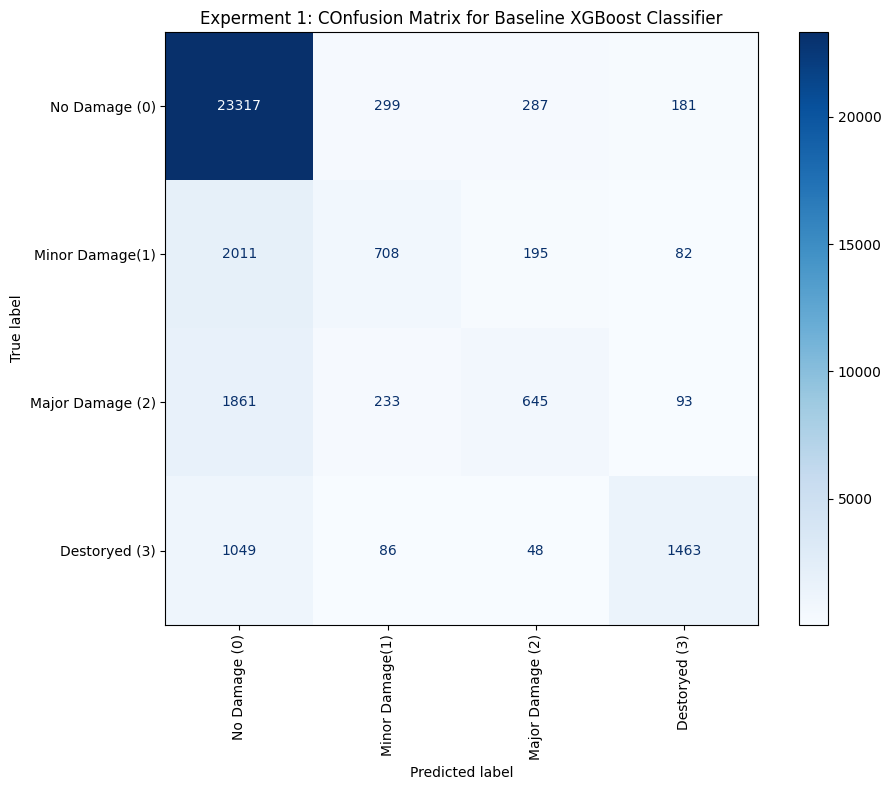

In [36]:
# Plotting Confusion Matrix:
cm= confusion_matrix(y_true= y_test,
                     y_pred= y_pred_classes)

disp= ConfusionMatrixDisplay(confusion_matrix= cm,
                             display_labels= target_names)

fig, ax= plt.subplots(figsize= (10,8))
disp.plot(ax= ax, cmap= 'Blues', xticks_rotation= 'vertical')
plt.title('Experment 1: COnfusion Matrix for Baseline XGBoost Classifier')
plt.tight_layout()
plt.show()

## Experiment 2: Mitigating Class Imbalance by Algorithmic Balancing

### Calculating Sample Weights

In [38]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights= compute_sample_weight(class_weight= 'balanced',
                                      y= y_train)

print(sample_weights)

[0.33795869 0.33795869 0.33795869 ... 0.33795869 2.87379733 3.07695397]


In [40]:
# Checking Class Weight Multiplier for Each Class:
unique_classes, counts = np.unique(y_train, return_counts=True)
unique_weights = np.unique(sample_weights)
print("Class Weight Multipliers:")
for cls, count, weight in zip(unique_classes, counts, unique_weights):
    print(f"Class {cls} ({count} samples): {weight:.4f}x penalty")

Class Weight Multipliers:
Class 0 (96335 samples): 0.3380x penalty
Class 1 (11984 samples): 2.7167x penalty
Class 2 (11329 samples): 2.8738x penalty
Class 3 (10581 samples): 3.0770x penalty
